In [3]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from sympy import symbols, sqrt, lambdify
from sympy import Poly, solve
from sympy import simplify, expand, factor, collect

In [4]:
v, thetaH, thetaL, sv, sc, sp, dc, pi, dp, c, alp, etaH, etaL, d = symbols('v theta_H theta_L s_v s_c s_p d_c pi d_p c alpha eta_H eta_L d', real=True, positive=True)


### Voter's strategies
#### When voter does not verify

In [5]:
#Voter's payoff when voting without verification
V_for_payoff = factor(simplify(expand(alp*(etaH + sv*dc) + ( 1 - alp)*(sv*dc+etaL))))
V_against_payoff = alp*( sv*dc) + ( 1 - alp)*(sv*dc )
V_payoff_dif = V_for_payoff - V_against_payoff
type(V_payoff_dif)
#The threshold above which voter will always vote for
alp_VF_thres = solve(V_payoff_dif, alp)[0]
alp_VF_thres

-eta_L/(eta_H - eta_L)

#### When voter verifies, they will Vote For if High quality and Vote Against if Low quality, with the assumption, $\mu_H > 0 $, $\mu_L < 0$ . The payoff is

In [6]:
V_Ve_payoff = simplify(alp*(etaH+ sv*dc-c) +(1 - alp)*( sv*dc -c))
V_Ve_payoff

alpha*eta_H - c + d_c*s_v

#### Case 1: High probability of High quality, ie. $\alpha_1 > \alpha_V$
(Voter will always vote for if not verifying) \
In this case, if $c_{voter} > c_{VH}$, the voter will always Vote For the proposer. If $c_{voter} < c_{VH}$, they will Verify and vote truthfully (due to the assumption)

###### Cost threshold above which voter does not verify (and Vote For): $c_{VH}$

In [7]:
V_cost_thres_Ve_HiAlp = solve(V_for_payoff - V_Ve_payoff, c)[0]
factor(simplify(expand(V_cost_thres_Ve_HiAlp)))

eta_L*(alpha - 1)

#### Case 2: Low probability of High quality, ie. $\alpha_1 < \alpha_V$
(Voter will always vote against if not verifying)\
In this case, if $c_{voter} > c_{VL}$, the voter will always Vote Against. If $c_{voter} < c_{VL}$, they will Verify and vote truthfully (due to the asssumptions about the value of high/low qualities and the deposits)

###### Cost threshold above which voter does not verify (and vote against): $c_{VL}$

In [8]:
V_cost_thres_Ve_LoAlp = solve(V_against_payoff - V_Ve_payoff, c)[0]
factor(simplify(expand(V_cost_thres_Ve_LoAlp)))

alpha*eta_H

In [9]:
c_VH = lambdify(['alpha'], V_cost_thres_Ve_HiAlp.subs([(etaH, 0.7), (etaL, -0.2)]))
c_VL = lambdify(['alpha'], V_cost_thres_Ve_LoAlp.subs([(etaH, 0.7), (etaL, -0.2)]))
print(alp_VF_thres.subs([(etaH, 0.7), (etaL, -0.2)]))
print((V_cost_thres_Ve_HiAlp))
print(type(V_cost_thres_Ve_HiAlp))

0.222222222222222
eta_L*(alpha - 1)
<class 'sympy.core.mul.Mul'>


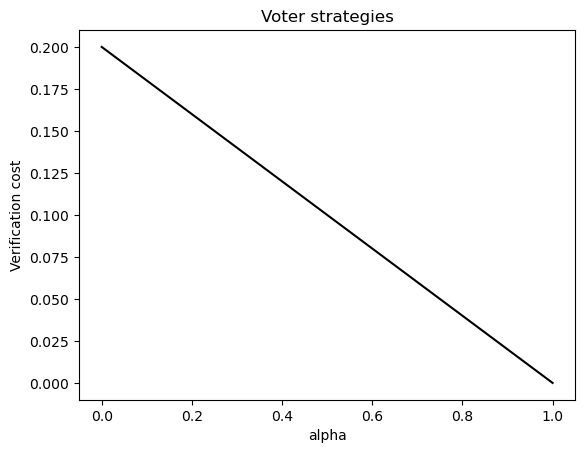

In [10]:
x = np.linspace(0,1,num=10)
plt.plot(x, c_VH(x), 'k')
#plt.plot(x, c_VL(x), 'b')
#plt.axvline(x=0.2)

plt.xlabel("alpha")
plt.ylabel('Verification cost')

plt.title('Voter strategies')
plt.show()

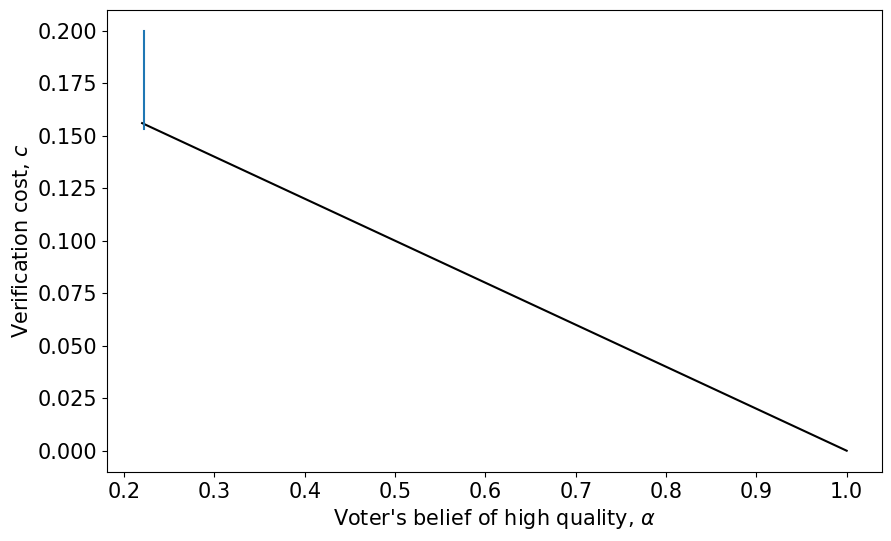

In [11]:
#NEW VALUE OF ETA_l: \ETA_L >0
plt.figure(figsize=(10, 6))
xl = np.linspace(0,0.22,10)
xh = np.linspace(0.22,1,10)
plt.rcParams['font.size'] = 15 

plt.plot(xh, c_VH(xh), 'k')

ya = np.linspace(0.153,0.2,10)
alp2 = np.full_like(ya, 0.222)
plt.plot(alp2, ya)
plt.xlabel(r"Voter's belief of high quality, $\alpha$")
plt.ylabel('Verification cost, $c$')

#plt.title('Voter strategies')
plt.show()

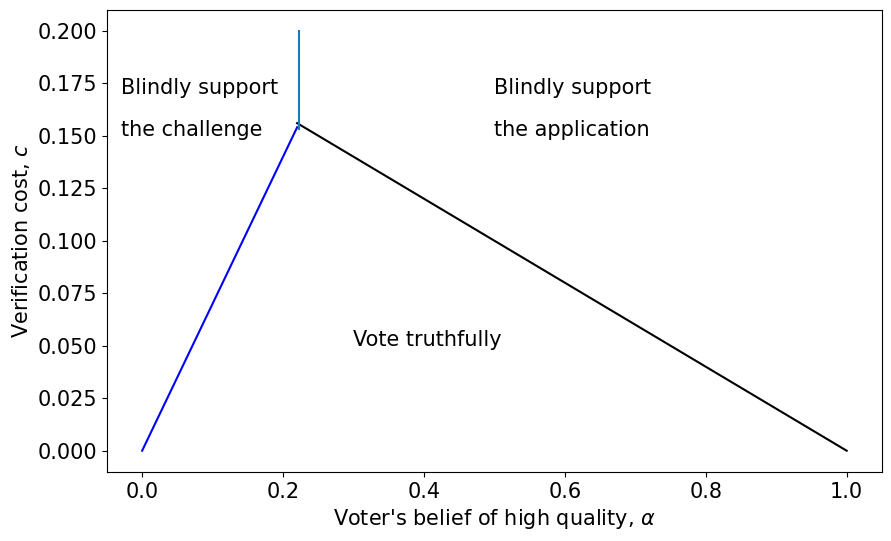

In [12]:
plt.figure(figsize=(10, 6))
xl = np.linspace(0,0.22,10)
xh = np.linspace(0.22,1,10)
plt.rcParams['font.size'] = 15 

plt.plot(xh, c_VH(xh), 'k')
plt.plot(xl, c_VL(xl), 'b')

ya = np.linspace(0.153,0.2,10)
alp0 = np.full_like(ya, 0.222)
plt.plot(alp0, ya)
plt.text(-.03, .17, "Blindly support")
plt.text(-.03, .15, "the challenge")
plt.text(.3, .05, "Vote truthfully")
plt.text(.5, .17, "Blindly support")
plt.text(.5, .15, "the application")
plt.xlabel(r"Voter's belief of high quality, $\alpha$")
plt.ylabel('Verification cost, $c$')

#plt.title('Voter strategies')
plt.show()

In [13]:
alp0_1 = (sc*d-etaL)/(etaH - etaL)
alp0_2 = 1 - c/(sc*d - etaL)
#alpC_1 = (sc*d-etaL)/(etaH - etaL)
alpC_2 = c/(etaH - sc*d)
# For when voter verifies and votes truthfully
alpC_3 = (sc*d - etaL)/(sc*d + d - etaL)
#Set the parameters values
([etaH_Pa, etaL_Pa, sc_Pa, c_Pa, alpha0, alphaC_1, alphaC_2]) = ([0.9, -0.4, 0.6, 0.2, 0.5, 0.3, 0.7])
al0_1 = lambdify(['d'], alp0_1.subs([(etaH, etaH_Pa), (etaL, etaL_Pa), (sc, sc_Pa)]))
al0_2 = lambdify(['d'], alp0_2.subs([(etaH, etaH_Pa), (etaL, etaL_Pa), (sc, sc_Pa), (c, c_Pa)]))
alC_2 = lambdify(['d'], alpC_2.subs([(etaH, etaH_Pa), (etaL, etaL_Pa), (sc, sc_Pa), (c, c_Pa)]))
alC_3 = lambdify(['d'], alpC_3.subs([(etaH, etaH_Pa), (etaL, etaL_Pa), (sc, sc_Pa), (c, c_Pa)]))


print(alC_2(1.3))
print("Alpha C function is ", alC_2)


theL=0.7
theH=1.5
theH_scd = theH/(1 - sc)
dthres = etaH/sc
dthres = dthres.subs([(etaH, etaH_Pa),(sc, sc_Pa)])
print("$eta_H/ s_c$ = ",dthres)
print(theH_scd.subs([(sc, 0.6)]))
print("The threshold reward for challenger to be truthful is ",dthres)
#--------------For the graph c on d--------------
#The first inequ in (42 revisited) - pooling - both apply
dthres2= (alpha0*(etaH_Pa - etaL_Pa) + etaL_Pa)/sc_Pa
print(dthres2)
#Cost threshold in (42 revisited)
c_1= (1 - alpha0)*(sc_Pa*d - etaL_Pa)
c_1 = lambdify(['d'], c_1)
print("c1 is ", c_1)
#Cost threshold in pro 3.3 part 1 and part 3 for LOW value of alpha C
c_2 = alphaC_1*(etaH_Pa - sc_Pa*d)
c_2 = lambdify(['d'], c_2)
#Cost threshold in pro 3.3 part 2 for LOW value of alpha C
c_3 = (1 - alphaC_1)*(sc_Pa*d - etaL_Pa)
c_3 = lambdify(['d'], c_3)
# d* from (42 revisited)
dstar_3 =  (alpha0*(etaH_Pa - etaL_Pa)+etaL_Pa)/sc_Pa
print(" Value of dstar_3 for LOW alpha C is ", dstar_3)
# d* from Pro 3.3 part 1, 2 for LOW value of alphaC
dstar_4 =  (alphaC_1*(etaH_Pa - etaL_Pa)+etaL_Pa)/sc_Pa
print("Value of dstar_4 for LOW alpha C is", dstar_4)

1.6666666666666667
Alpha C function is  <function _lambdifygenerated at 0x0000027541D31B20>
$eta_H/ s_c$ =  1.50000000000000
3.75000000000000
The threshold reward for challenger to be truthful is  1.50000000000000
0.4166666666666667
c1 is  <function _lambdifygenerated at 0x0000027541D322A0>
 Value of dstar_3 for LOW alpha C is  0.4166666666666667
Value of dstar_4 for LOW alpha C is -0.016666666666666684


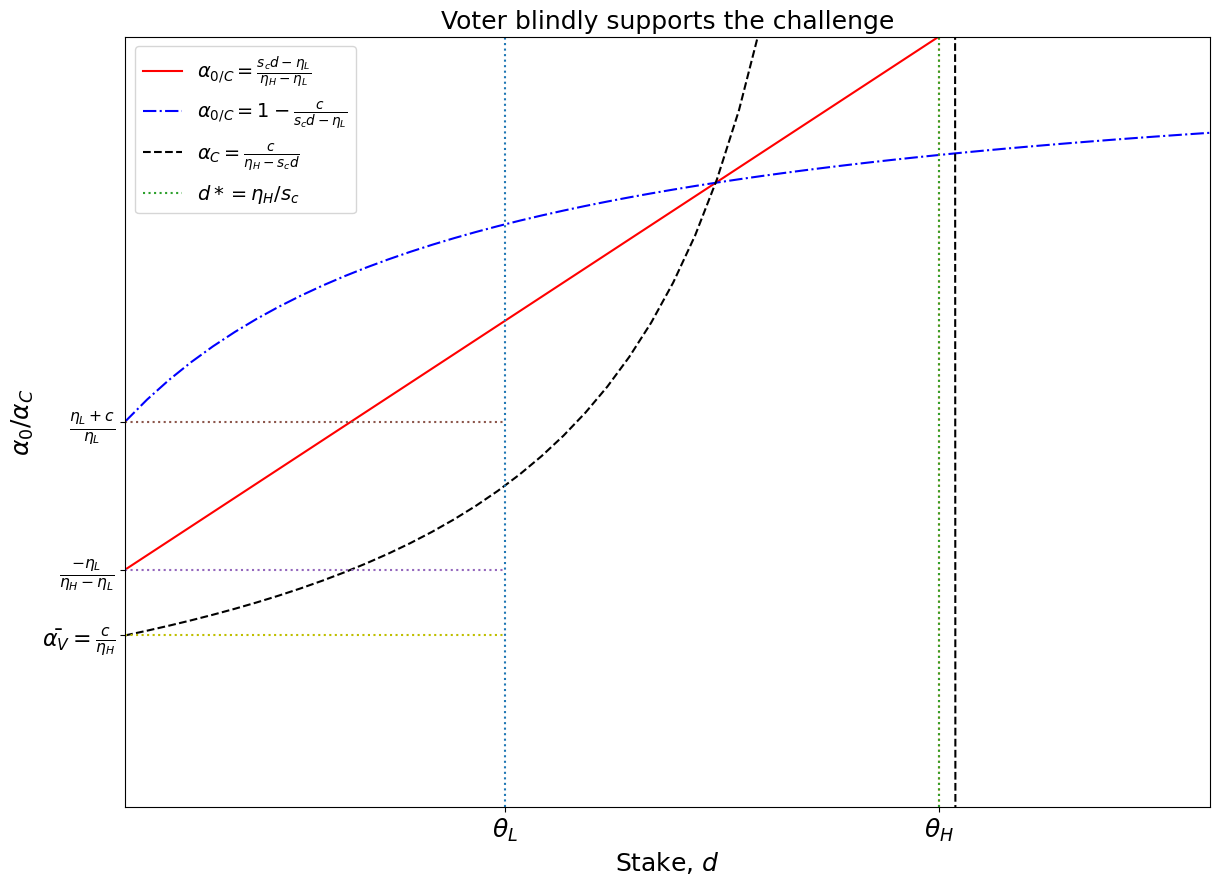

In [14]:
plt.figure(figsize=(14, 10))
#Set the functions for the graph


x1 = np.linspace(0,theL,num=100)
x = np.linspace(0,4,num=100)
#x2 = np.linspace(1.5, 4, num = 100)

plt.plot(x, al0_1(x),'r', label=r'$\alpha_{0/C}= \frac{s_c d - \eta_L}{\eta_H - \eta_L}$')
plt.plot(x, al0_2(x),'b-.', label = r'$\alpha_{0/C} = 1 - \frac{c}{s_cd - \eta_L}$')
plt.plot(x, alC_2(x),'k--', label = r'$\alpha_C = \frac{c}{\eta_H - s_cd}$')
#plt.plot(x2, alC_3(x2),'g--', label = r'Belief $\alpha_C$')
#plt.plot(x2, alC_4(x2),'m--', label = r'Belief $\alpha_C$')

theL_ar = np.full_like(x, theL)
plt.plot(theL_ar, x, ':')
theH_ar = np.full_like(x, theH)
plt.plot(theH_ar, x, ':')
#Threshold for challenger to challenge truthfully when \thetaH > d > \theta
dstar = np.full_like(x, dthres)
plt.plot(dstar, x, ':', label=r"$d*= \eta_H/s_c$")
#From theH_scd(0.6)
dstar2 = np.full_like(x, 3.75)
plt.plot(dstar2, x, ':')

alV_1 = (c_Pa/etaH_Pa) * np.ones_like(x1)  # Constant value 3 for the range
plt.plot(x1, alV_1, 'y:')
alV_2 = (-etaL_Pa/(etaH_Pa-etaL_Pa))* np.ones_like(x1)
plt.plot(x1, alV_2, ':')
alV_3 = ((etaL_Pa + c_Pa)/etaL_Pa)* np.ones_like(x1)
plt.plot(x1, alV_3, ':')


#Threshold for challenger to challenge truthfully when \thetaH > d > \theta
dstar2 = np.full_like(x, 3.75)
plt.plot(dstar2, x, ':')
plt.xticks([0.7, 1.5], [r"$\theta_L$", r"$\theta_H$"], fontsize=18)
plt.yticks([c_Pa/etaH_Pa, -etaL_Pa/(etaH_Pa-etaL_Pa), (etaL_Pa + c_Pa)/etaL_Pa], [r'$\bar{\alpha_V} = \frac{c}{\eta_H}$', r'$\frac{-\eta_L}{\eta_H - \eta_L}$', r"$\frac{\eta_L + c}{\eta_L}$"], fontsize=16)


plt.xticks([0.7, 1.5, 3.75], [r"$\theta_L$", r"$\theta_H$", r"$\frac{\theta_H}{1-s_C}$"], fontsize=18)


plt.axis([0, 2, 0, 1])

#plt.text(1.16, .2, "<= $\eta_H/s_c$")
#plt.text(0.6, 0.2, "Separating equilibria")
plt.ylabel( r"$\alpha_0/\alpha_C$ ",fontsize=18)
plt.xlabel(r'Stake, $d$', fontsize=18)
plt.title('Voter blindly supports the challenge', fontsize=18)
plt.legend(fontsize=14)
plt.show()

Graph of alpha, the condition in Proposition 2b and Proposition 3

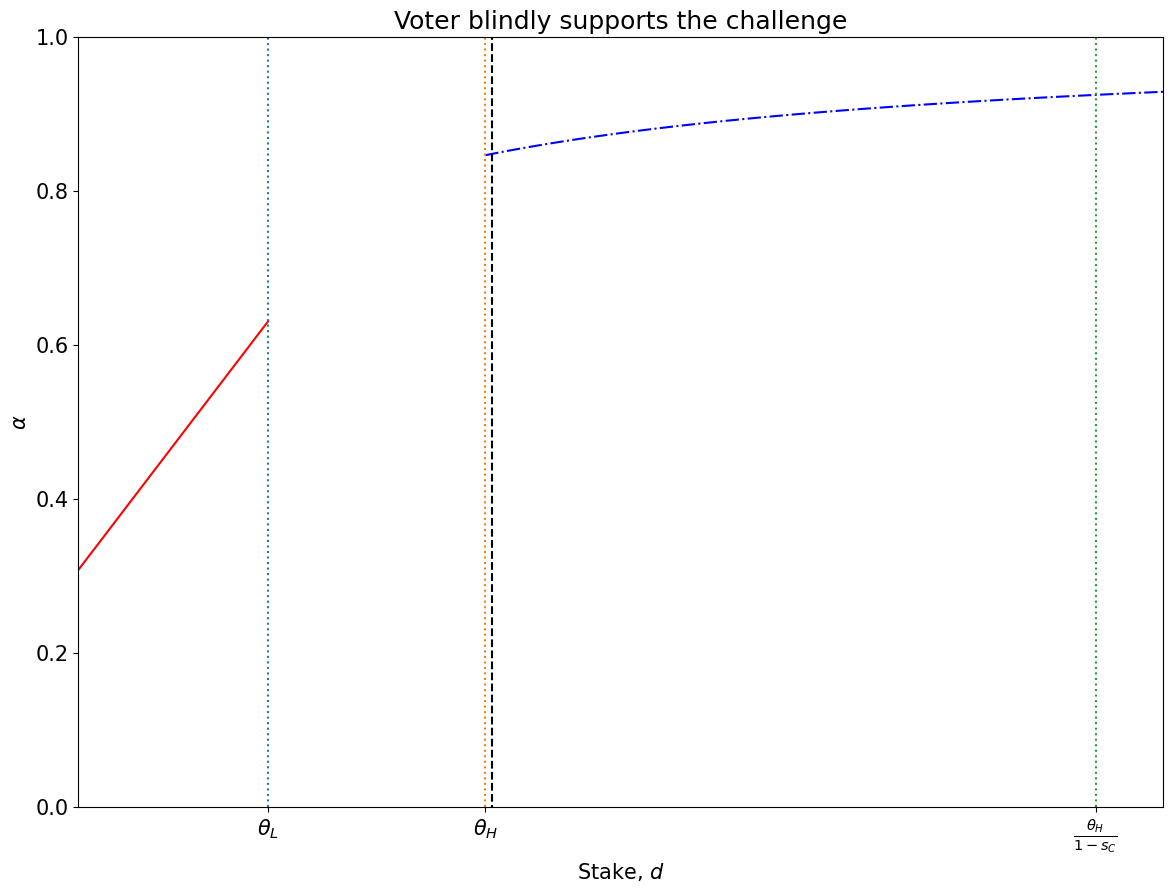

In [15]:
plt.figure(figsize=(14, 10))
#Set the functions for the graph



x = np.linspace(0,4,num=100)
z = np.linspace(theH,4,num=100)
y = np.linspace(0, theL, num=100)

plt.plot(y, al0_1(y),'r', label=r'$\alpha_{0/C}= \frac{s_c d - \eta_L}{\eta_H - \eta_L}$')
plt.plot(z, al0_2(z),'b-.', label = r'$\alpha_{0/C} = 1 - \frac{c}{s_cd - \eta_L}$')
plt.plot(z, alC_2(z),'k--', label = r'$\alpha_C = \frac{c}{\eta_H - s_cd}$')
#plt.plot(x2, alC_3(x2),'g--', label = r'Belief $\alpha_C$')
#plt.plot(x2, alC_4(x2),'m--', label = r'Belief $\alpha_C$')

theL_ar = np.full_like(x, theL)
plt.plot(theL_ar, x, ':')
theH_ar = np.full_like(x, theH)
plt.plot(theH_ar, x, ':')
#Threshold for challenger to challenge truthfully when \thetaH > d > \theta
#dstar = np.full_like(x, 1.33)
#plt.plot(dstar, x, ':', label=r"$d*= \eta_H/s_c$")
#From theH_scd(0.6)
dstar2 = np.full_like(x, 3.75)
plt.plot(dstar2, x, ':')
plt.xticks([0.7, 1.5, 3.75], [r"$\theta_L$", r"$\theta_H$", r"$\frac{\theta_H}{1-s_C}$"])


plt.axis([0, 4, 0, 1])

#plt.text(1.16, .2, "<= $\eta_H/s_c$")
#plt.text(0.6, 0.2, "Separating equilibria")
plt.ylabel( r"$\alpha$ ")
plt.xlabel(r'Stake, $d$')
plt.title('Voter blindly supports the challenge')
#plt.legend()
plt.show()

In [16]:
#Alpha0  at Pro 3.2, (43 revisited)
al0_3 = (sc_Pa*d - etaL_Pa)/(sc_Pa*d + d - etaL_Pa)
al0_3 = lambdify(['d'], al0_3)
#Alpha 0 at Pro 3.3, part 4
alC_4 = c_Pa / d
alC_4 = lambdify(['d'], alC_4)
print(r"\theta_H/(1 - s_C) is ", theH_scd.subs([(sc, 0.6)]))

\theta_H/(1 - s_C) is  3.75000000000000


<lambdifygenerated-11>:2: RuntimeWarning: divide by zero encountered in divide
  return 0.2/d


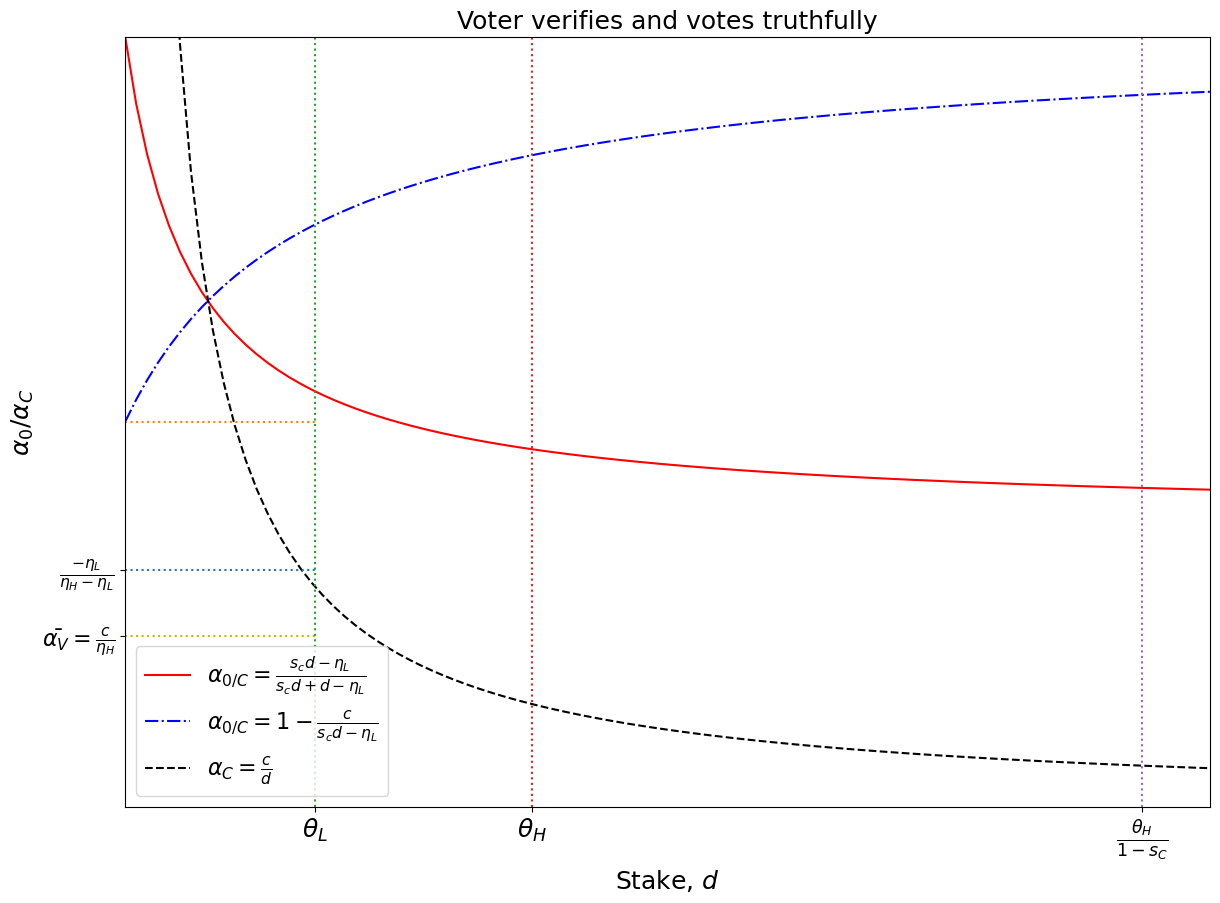

In [17]:
#GRAPH OF ALPHAc ON D - VOTER'S BELIEF OF VERIFICATION TRUTHFULLY


plt.figure(figsize=(14, 10))
#Set the functions for the graph
x1 = np.linspace(0,theL,num=100)
x = np.linspace(0,4,num=100)
#x2 = np.linspace(1.5, 4, num = 100)

plt.plot(x, al0_3(x),'r', label=r'$\alpha_{0/C}= \frac{s_c d - \eta_L}{s_cd + d - \eta_L}$')
plt.plot(x, al0_2(x),'b-.', label = r'$\alpha_{0/C} = 1 - \frac{c}{s_cd - \eta_L}$')
plt.plot(x, alC_4(x),'k--', label = r'$\alpha_C = \frac{c}{d}$')
#plt.plot(x2, alC_3(x2),'g--', label = r'Belief $\alpha_C$')
#plt.plot(x2, alC_4(x2),'m--', label = r'Belief $\alpha_C$')

alV_1 = (c_Pa/etaH_Pa) * np.ones_like(x1)  # Constant value 3 for the range
plt.plot(x1, alV_1, 'y:')
alV_2 = (-etaL_Pa/(etaH_Pa-etaL_Pa))* np.ones_like(x1)
plt.plot(x1, alV_2, ':')
alV_3 = ((etaL_Pa + c_Pa)/etaL_Pa)* np.ones_like(x1)
plt.plot(x1, alV_3, ':')


theL_ar = np.full_like(x, theL)
plt.plot(theL_ar, x, ':')
theH_ar = np.full_like(x, theH)
plt.plot(theH_ar, x, ':')
#Threshold for challenger to challenge truthfully when \thetaH > d > \theta
dstar2 = np.full_like(x, 3.75)
plt.plot(dstar2, x, ':')
plt.xticks([0.7, 1.5, 3.75], [r"$\theta_L$", r"$\theta_H$", r"$\frac{\theta_H}{1-s_C}$"], fontsize=18)
plt.yticks([c_Pa/etaH_Pa, -etaL_Pa/(etaH_Pa-etaL_Pa)], [r'$\bar{\alpha_V} = \frac{c}{\eta_H}$', r'$\frac{-\eta_L}{\eta_H - \eta_L}$'], fontsize=16)

plt.axis([0, 4, 0, 1])

#plt.text(1.16, .2, "<= $\eta_H/s_c$")
#plt.text(0.6, 0.2, "Separating equilibria")
plt.ylabel( r"$\alpha_0/\alpha_C$ ",fontsize=18)
plt.xlabel(r'Stake, $d$', fontsize=18)
plt.title('Voter verifies and votes truthfully', fontsize=18)
# Remove duplicates in the legend
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(),fontsize=16)
plt.show()

<lambdifygenerated-11>:2: RuntimeWarning: divide by zero encountered in divide
  return 0.2/d


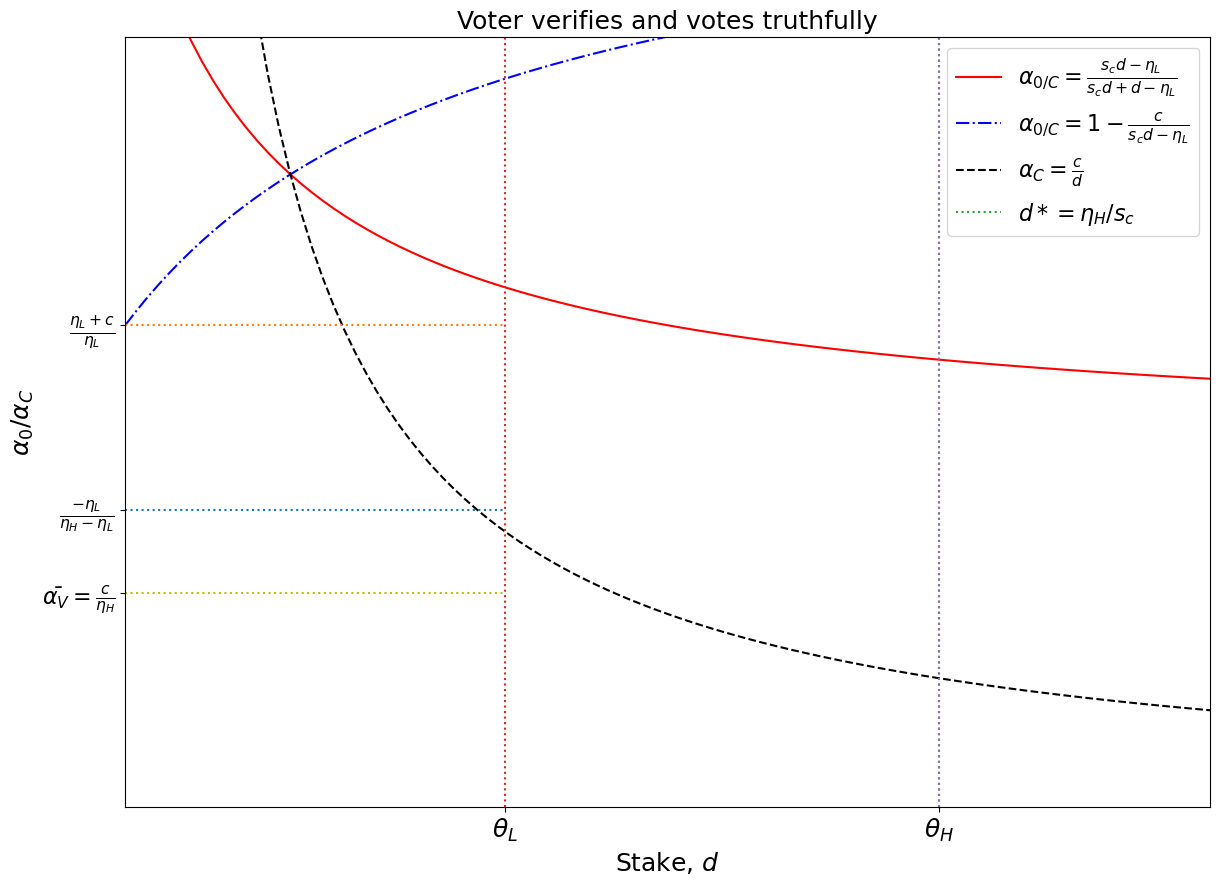

In [18]:
#GRAPH OF ALPHAc ON D - VOTER'S BELIEF OF VERIFICATION TRUTHFULLY


plt.figure(figsize=(14, 10))
#Set the functions for the graph
x1 = np.linspace(0,theL,num=100)
x = np.linspace(0,2,num=100)
#x2 = np.linspace(1.5, 4, num = 100)

plt.plot(x, al0_3(x),'r', label=r'$\alpha_{0/C}= \frac{s_c d - \eta_L}{s_cd + d - \eta_L}$')
plt.plot(x, al0_2(x),'b-.', label = r'$\alpha_{0/C} = 1 - \frac{c}{s_cd - \eta_L}$')
plt.plot(x, alC_4(x),'k--', label = r'$\alpha_C = \frac{c}{d}$')
#plt.plot(x2, alC_3(x2),'g--', label = r'Belief $\alpha_C$')
#plt.plot(x2, alC_4(x2),'m--', label = r'Belief $\alpha_C$')

alV_1 = (c_Pa/etaH_Pa) * np.ones_like(x1)  # Constant value 3 for the range
plt.plot(x1, alV_1, 'y:')
alV_2 = (-etaL_Pa/(etaH_Pa-etaL_Pa))* np.ones_like(x1)
plt.plot(x1, alV_2, ':')
alV_3 = ((etaL_Pa + c_Pa)/etaL_Pa)* np.ones_like(x1)
plt.plot(x1, alV_3, ':')
dstar = np.full_like(x, dthres)
plt.plot(dstar, x, ':', label=r"$d*= \eta_H/s_c$")




theL_ar = np.full_like(x, theL)
plt.plot(theL_ar, x, ':')
theH_ar = np.full_like(x, theH)
plt.plot(theH_ar, x, ':')
#Threshold for challenger to challenge truthfully when \thetaH > d > \theta
dstar2 = np.full_like(x, 3.75)
plt.plot(dstar2, x, ':')
plt.xticks([0.7, 1.5], [r"$\theta_L$", r"$\theta_H$"], fontsize=18)
plt.yticks([c_Pa/etaH_Pa, -etaL_Pa/(etaH_Pa-etaL_Pa), (etaL_Pa + c_Pa)/etaL_Pa], [r'$\bar{\alpha_V} = \frac{c}{\eta_H}$', r'$\frac{-\eta_L}{\eta_H - \eta_L}$', r"$\frac{\eta_L + c}{\eta_L}$"], fontsize=16)

plt.axis([0, 2, 0, 0.8])

#plt.text(1.16, .2, "<= $\eta_H/s_c$")
#plt.text(0.6, 0.2, "Separating equilibria")
plt.ylabel( r"$\alpha_0/\alpha_C$ ",fontsize=18)
plt.xlabel(r'Stake, $d$', fontsize=18)
plt.title('Voter verifies and votes truthfully', fontsize=18)
# Remove duplicates in the legend
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(),fontsize=16)
plt.show()

# PBNEs no.1

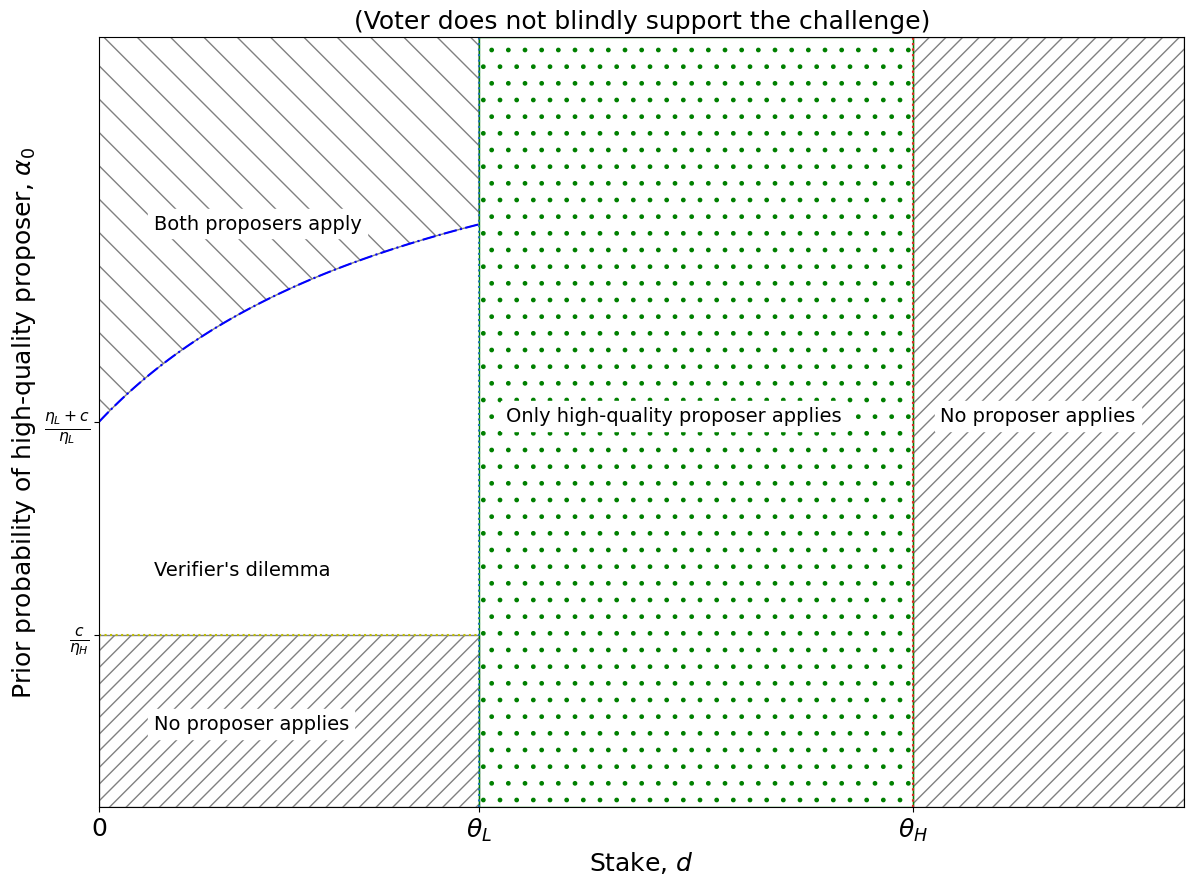

numpy.ndarray

In [26]:
#GRAPH OF ALPHAc ON D - VOTER'S BELIEF OF VERIFICATION TRUTHFULLY


plt.figure(figsize=(14, 10))
#Set the functions for the graph
x1 = np.linspace(0,theL,num=100)
y = np.linspace(theL, theH, num = 100)
z = np.linspace(theH, 2, num=100)
x = np.concatenate([x1, y, z])


#plt.plot(x, al0_3(x),'r', label=r'$\alpha_{0/C}= \frac{s_c d - \eta_L}{s_cd + d - \eta_L}$')
plt.plot(x1, al0_2(x1),'b-.', label = r'$\alpha_{0/C} = 1 - \frac{c}{s_cd - \eta_L}$')
#plt.plot(x, alC_4(x),'k--', label = r'$\alpha_C = \frac{c}{d}$')

alV_1 = (c_Pa/etaH_Pa) * np.ones_like(x1)  # Constant value 3 for the range
plt.plot(x1, alV_1, 'y:')


theL_ar = np.full_like(x, theL)
plt.plot(theL_ar, x, ':')
theH_ar = np.full_like(x, theH)
plt.plot(theH_ar, x, ':')
#Threshold for challenger to challenge truthfully when \thetaH > d > \theta
dstar2 = np.full_like(x, 3.75)
plt.plot(dstar2, x, ':')
dstar = np.full_like(x, dthres)
plt.plot(dstar, x, ':', label=r"$d*= \eta_H/s_c$")
plt.xticks([0, 0.7, 1.5], ["0", r"$\theta_L$", r"$\theta_H$"], fontsize=18)
plt.yticks([c_Pa/etaH_Pa, (etaL_Pa + c_Pa)/etaL_Pa], [r'$\frac{c}{\eta_H}$', r"$\frac{\eta_L + c}{\eta_L}$"], fontsize=16)

plt.axis([0, 2, 0, 1])

#HIGHTLIGHT THE AREAS
aV_1= c_Pa/etaH_Pa
a0_1 = (sc_Pa*x-etaL_Pa)/(etaH_Pa - etaL_Pa)
a0_2 = 1 - c_Pa/(sc_Pa*x1 - etaL_Pa)
a0_2= np.array(a0_2, dtype=float)
plt.fill_between(x1, a0_2, 1, facecolor="none", edgecolor="gray", hatch='\\', label="Both types of proposer applies")

plt.fill_between(x1, aV_1, 0,  facecolor="none", edgecolor="gray", hatch='//', label="No proposer applies")
plt.fill_between(z, 1, 0, facecolor="none", edgecolor="gray", hatch='//', label="No proposer applies")
plt.fill_between(y, 1, 0, facecolor="none", edgecolor="green", hatch='.', label="Only high-quality proposer applies")


plt.text(.1, .3, "Verifier's dilemma", backgroundcolor='white',fontsize=14)
plt.text(.1, .75, "Both proposers apply", backgroundcolor='white',fontsize=14)
plt.text(.75, .5, "Only high-quality proposer applies", backgroundcolor='white',fontsize=14)
plt.text(.1, .1, "No proposer applies", backgroundcolor='white',fontsize=14)
plt.text(1.55, .5, "No proposer applies", backgroundcolor='white',fontsize=14)

#plt.text(0.6, 0.2, "Separating equilibria")
plt.ylabel( r"Prior probability of high-quality proposer, $\alpha_0$ ",fontsize=18)
plt.xlabel(r'Stake, $d$', fontsize=18)
plt.title('(Voter does not blindly support the challenge)', fontsize=18)
# Remove duplicates in the legend
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
#plt.legend(unique.values(), unique.keys(),fontsize=16)
plt.show()
type(a0_1)

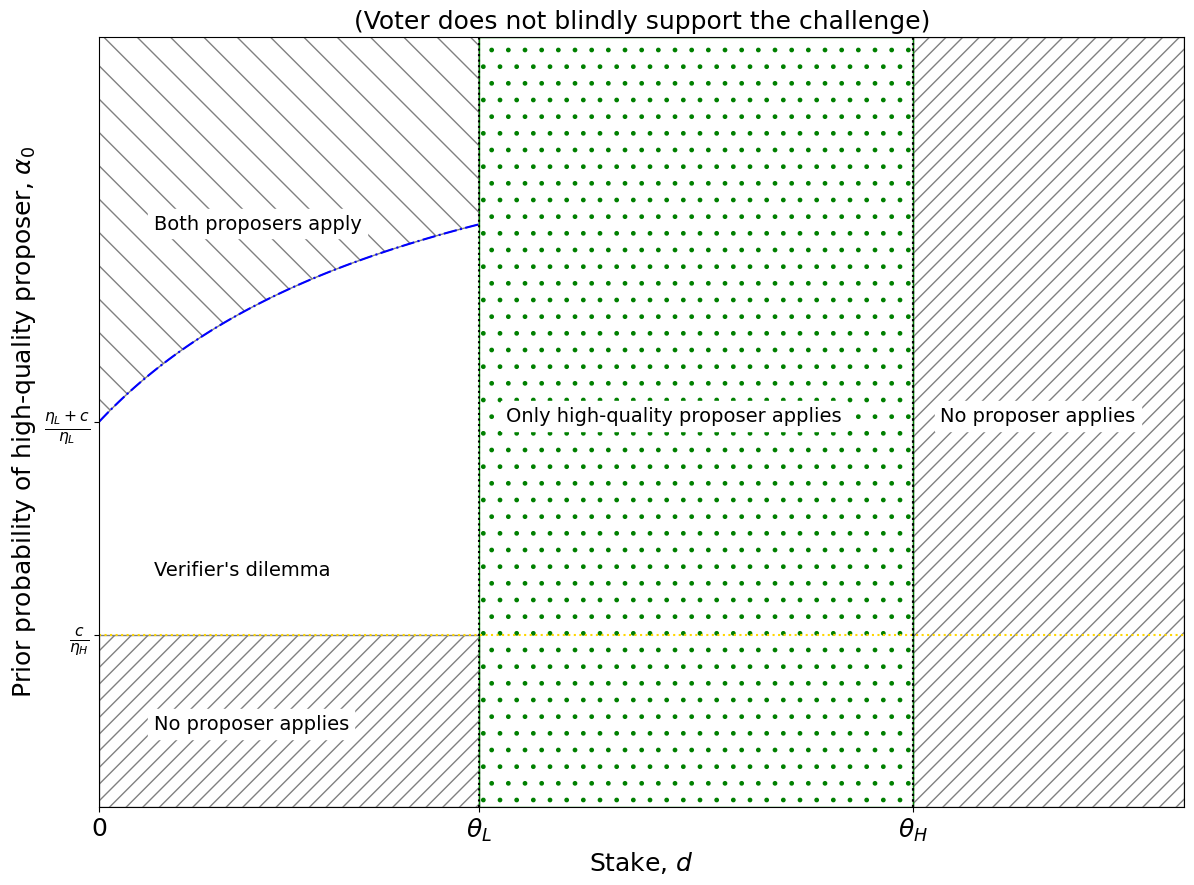

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# --- Grid ---
x1 = np.linspace(0, theL, 100)
y  = np.linspace(theL, theH, 100)
z  = np.linspace(theH, 2, 100)
x  = np.concatenate([x1, y, z])

# --- Key functions ---
a0_2 = 1 - c_Pa / (sc_Pa * x1 - etaL_Pa)
a0_1 = (sc_Pa * x - etaL_Pa) / (etaH_Pa - etaL_Pa)

alpha_v = c_Pa / etaH_Pa  # constant threshold

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 10))

# Main curve
ax.plot(x1, a0_2, 'b-.',
        label=r'$\alpha_{0/C} = 1 - \frac{c}{s_cd - \eta_L}$')

# Horizontal threshold
(c_Pa/etaH_Pa) * np.ones_like(x1)

# Vertical reference lines
ax.axvline(theL, linestyle=':', color='black')
ax.axvline(theH, linestyle=':', color='black')
ax.axvline(3.75, linestyle=':', color='black')   # fixed threshold
ax.axvline(dthres, linestyle=':', color='black',
           label=r"$d^* = \eta_H/s_c$")

# --- Regions ---
ax.fill_between(x1, a0_2, 1,
                facecolor="none", edgecolor="gray", hatch='\\',
                label="Both proposers apply")

ax.fill_between(x1, alpha_v, 0,
                facecolor="none", edgecolor="gray", hatch='//',
                label="No proposer applies")

ax.fill_between(z, 0, 1,
                facecolor="none", edgecolor="gray", hatch='//')

ax.fill_between(y, 0, 1,
                facecolor="none", edgecolor="green", hatch='.',
                label="Only high-quality proposer applies")

# --- Axes ---
ax.set_xlim(0, 2)
ax.set_ylim(0, 1)

ax.set_xticks([0, theL, theH])
ax.set_xticklabels(["0", r"$\theta_L$", r"$\theta_H$"], fontsize=18)

ax.set_yticks([alpha_v, (etaL_Pa + c_Pa) / etaL_Pa])
ax.set_yticklabels([r'$\frac{c}{\eta_H}$',
                    r"$\frac{\eta_L + c}{\eta_L}$"],
                   fontsize=16)

# --- Labels ---
ax.set_xlabel(r'Stake, $d$', fontsize=18)
ax.set_ylabel(r"Prior probability of high-quality proposer, $\alpha_0$", fontsize=18)
ax.set_title('(Voter does not blindly support the challenge)', fontsize=18)

# --- Annotations ---
ax.text(.1, .3, "Verifier's dilemma", backgroundcolor='white', fontsize=14)
ax.text(.1, .75, "Both proposers apply", backgroundcolor='white', fontsize=14)
ax.text(.75, .5, "Only high-quality proposer applies", backgroundcolor='white', fontsize=14)
ax.text(.1, .1, "No proposer applies", backgroundcolor='white', fontsize=14)
ax.text(1.55, .5, "No proposer applies", backgroundcolor='white', fontsize=14)

# --- Legend (deduplicated) ---
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
# ax.legend(unique.values(), unique.keys(), fontsize=16)

plt.show()

# PBNEs no.2

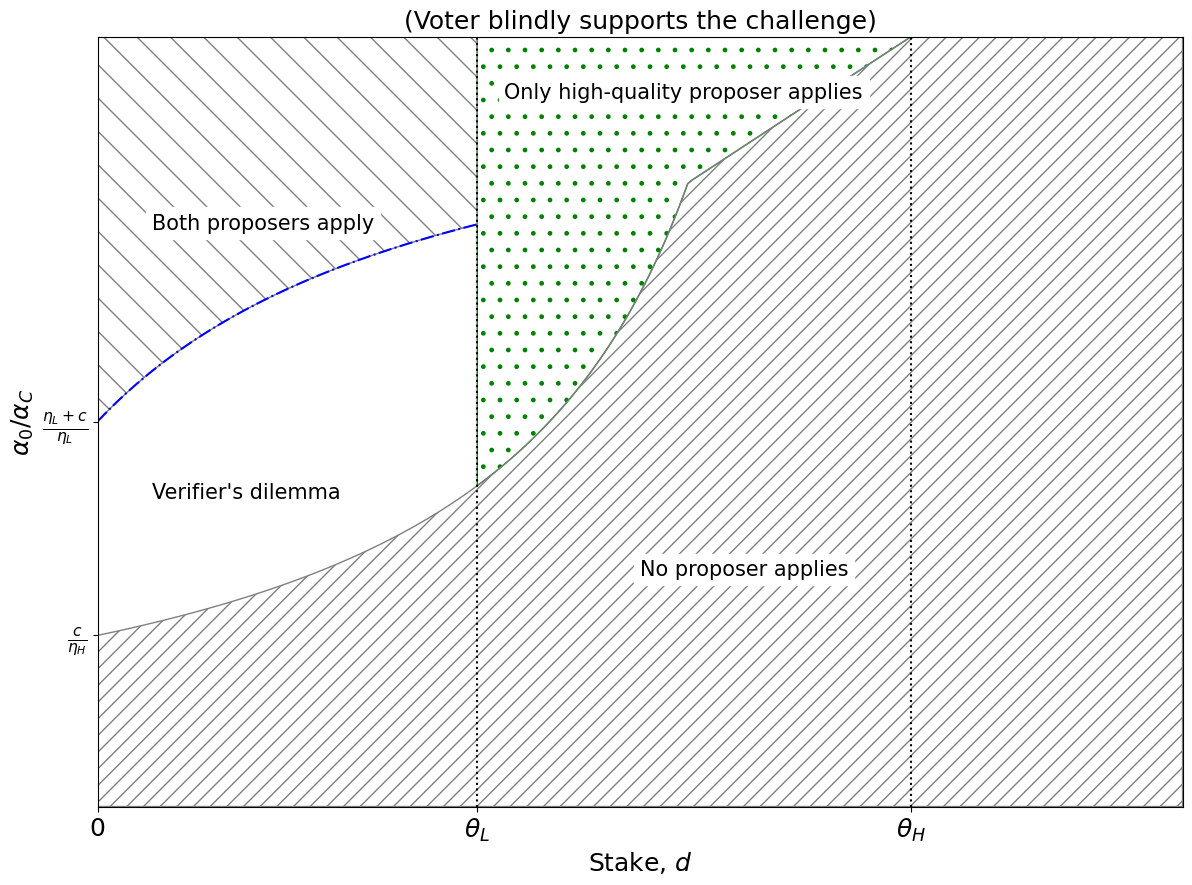

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# --- Create grid ---
x1 = np.linspace(0, theL, 100)
z  = np.linspace(theL, theH, 100)
y  = np.linspace(theH, 2, 100)
x  = np.concatenate([x1, z, y])

# --- Precompute constants ---
alpha_v1 = c_Pa / etaH_Pa
alpha_v2 = -etaL_Pa / (etaH_Pa - etaL_Pa)
alpha_v3 = (etaL_Pa + c_Pa) / etaL_Pa

# --- Functions ---
a0_1 = (sc_Pa * z - etaL_Pa) / (etaH_Pa - etaL_Pa)
aC_2 = c_Pa / (etaH_Pa - sc_Pa * z)
a0_2 = 1 - c_Pa / (sc_Pa * x1 - etaL_Pa)
aC_2_x1 = c_Pa / (etaH_Pa - sc_Pa * x1)

# --- Combine regions ---
a1 = np.minimum(a0_1, aC_2)
a2 = np.concatenate([aC_2_x1, a1, np.ones_like(y)])

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 10))

# Main curve
ax.plot(x1, a0_2, 'b-.', 
        label=r'$\alpha_{0/C} = 1 - \frac{c}{s_cd - \eta_L}$')

# Vertical reference lines
ax.axvline(theL, linestyle=':', color='black')
ax.axvline(theH, linestyle=':', color='black')
ax.axvline(3.75, linestyle=':', color='black')  # d*

# --- Filled regions ---
ax.fill_between(z, a1, 1, facecolor="none", edgecolor="green",
                hatch='.', label="High types of proposer applies")

ax.fill_between(x, a2, 0, facecolor="none", edgecolor="grey",
                hatch='//', label="No proposer applies")

ax.fill_between(x1, a0_2, 1, facecolor="none", edgecolor="gray",
                hatch='\\', label="Both types of proposer applies")

# --- Labels & formatting ---
ax.set_xlim(0, 2)
ax.set_ylim(0, 1)

ax.set_xticks([0, theL, theH])
ax.set_xticklabels(["0", r"$\theta_L$", r"$\theta_H$"], fontsize=18)

ax.set_yticks([alpha_v1, alpha_v3])
ax.set_yticklabels([r'$\frac{c}{\eta_H}$', r"$\frac{\eta_L + c}{\eta_L}$"],
                   fontsize=16)

ax.set_xlabel(r'Stake, $d$', fontsize=18)
ax.set_ylabel(r"$\alpha_0/\alpha_C$", fontsize=18)
ax.set_title('(Voter blindly supports the challenge)', fontsize=18)

# Region labels
ax.text(.1, .4, "Verifier's dilemma", backgroundcolor='white')
ax.text(.1, .75, "Both proposers apply", backgroundcolor='white')
ax.text(.75, .92, "Only high-quality proposer applies", backgroundcolor='white')
ax.text(1, .3, "No proposer applies", backgroundcolor='white')

# Optional legend
# ax.legend(fontsize=14)

plt.show()

### Random

In [2]:
#GRAPH OF C ON D
plt.figure(figsize=(14, 10))
#Set the functions for the graph


x1 = np.linspace(0,0.5,num=100)
x = np.linspace(0,3,num=100)

plt.plot(x, c_1(x),'r', label=r'$(1 - \alpha_0)(s_cd - \eta_L)$')
plt.plot(x, c_2(x),'b-.', label = r'$\alpha_C(\eta_H - s_cd)$')
plt.plot(x, c_3(x),'k--', label = r'$(1 - \alpha_C)(s_cd - \eta_L)$')
#plt.plot(x2, alC_3(x2),'g--', label = r'Belief $\alpha_C$')
#plt.plot(x2, alC_4(x2),'m--', label = r'Belief $\alpha_C$')

theL = np.full_like(x, theL)
plt.plot(theL, x, ':')
theH = np.full_like(x, theH)
plt.plot(theH, x, ':')
#Threshold for challenger to challenge truthfully when \thetaH > d > \theta
dstar = np.full_like(x, 1.33)
plt.plot(dstar, x, ':')
dst3 = np.full_like(x, dstar_3)
plt.plot(dst3, x, ':')
dst4 = np.full_like(x, dstar_4)
plt.plot(dst4, x, ':')
plt.xticks([0.7, 1.5, 1.33, dstar_3, dstar_4], [r"$\theta_L$", r"$\theta_H$", r"$\frac{\eta_H}{s_C}$", r"$\frac{\alpha_0(\eta_H - \eta_L)+\eta_L}{s_c}$", r"$\frac{\alpha_C(\eta_H - \eta_L)+\eta_L}{s_c}$"], fontsize=18)

plt.axis([0, , 0, 1])

#plt.text(1.16, .2, "<= $\eta_H/s_c$")
#plt.text(0.6, 0.2, "Separating equilibria")
plt.ylabel( r"$c$ ", fontsize=18)
plt.xlabel(r'Stake, $d$', fontsize=18)
plt.title(r'Voter blindly supports the challenge, $\alpha_C<\alpha_0$', fontsize=18)
plt.legend()
plt.show()

SyntaxError: invalid syntax (3228810693.py, line 28)

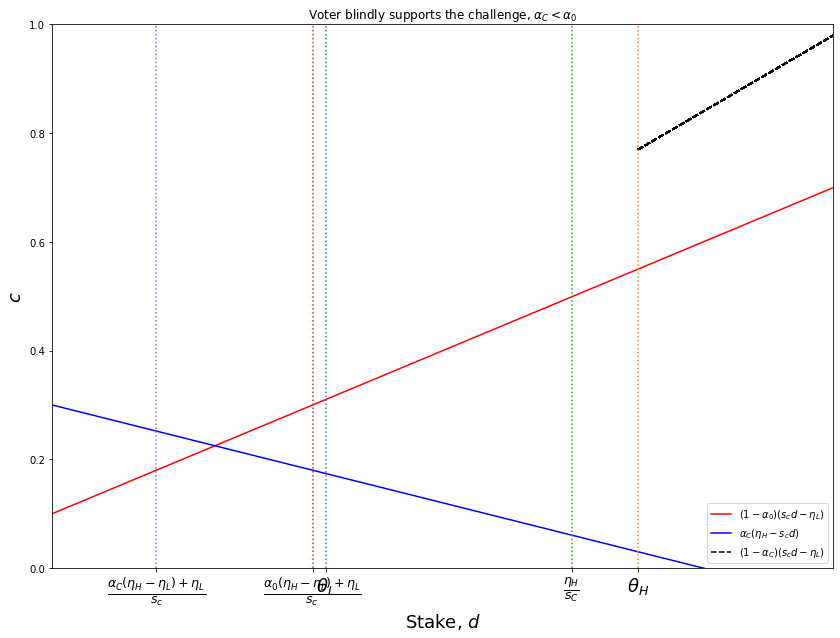

In [18]:
#GRAPH OF C ON D
plt.figure(figsize=(14, 10))
#Set the functions for the graph

x = np.linspace(0,2,num=100)
z = np.linspace(theH,2,num=100)
y = np.linspace(0, theL, num=100)

plt.plot(x, c_1(x),'r', label=r'$(1 - \alpha_0)(s_cd - \eta_L)$')
plt.plot(x, c_2(x),'b', label = r'$\alpha_C(\eta_H - s_cd)$')
plt.plot(z, c_3(z),'k--', label = r'$(1 - \alpha_C)(s_cd - \eta_L)$')


theL = np.full_like(x, theL)
plt.plot(theL, x, ':')
theH = np.full_like(x, theH)
plt.plot(theH, x, ':')
#Threshold for challenger to challenge truthfully when \thetaH > d > \theta
dstar = np.full_like(x, 1.33)
plt.plot(dstar, x, ':')
dst3 = np.full_like(x, dstar_3)
plt.plot(dst3, x, ':')
dst4 = np.full_like(x, dstar_4)
plt.plot(dst4, x, ':')
plt.xticks([0.7, 1.5, 1.33, dstar_3, dstar_4], [r"$\theta_L$", r"$\theta_H$", r"$\frac{\eta_H}{s_C}$", r"$\frac{\alpha_0(\eta_H - \eta_L)+\eta_L}{s_c}$", r"$\frac{\alpha_C(\eta_H - \eta_L)+\eta_L}{s_c}$"], fontsize=18)


plt.axis([0, 2, 0, 1])

#plt.text(1.16, .2, "<= $\eta_H/s_c$")
#plt.text(0.6, 0.2, "Separating equilibria")
plt.ylabel( r"$c$ ", fontsize=18)
plt.xlabel(r'Stake, $d$', fontsize=18)
plt.title(r'Voter blindly supports the challenge, $\alpha_C<\alpha_0$')
# Remove duplicates in the legend
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys())

plt.show()



Value of dstar_4 for LOW alpha C is 1.0666666666666667


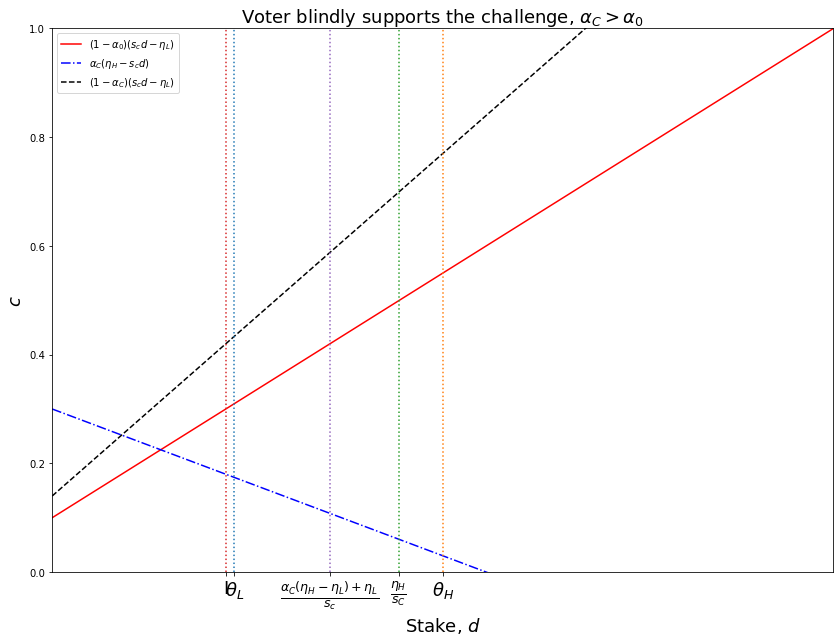

In [19]:
#Cost threshold in pro 3.3 part 1 and part 3 for LOW value of alpha C
c_4 = alphaC_2*(etaH_Pa - sc_Pa*d)
c_4 = lambdify(['d'], c_4)
#Cost threshold in pro 3.3 part 2 for LOW value of alpha C
c_5 = (1 - alphaC_2)*(sc_Pa*d - etaL_Pa)
c_5 = lambdify(['d'], c_5)
# d* from Pro 3.3 part 1, 2 for HIGH value of alphaC
dstar_5 =  (alphaC_2*(etaH_Pa - etaL_Pa)+etaL_Pa)/sc_Pa
print("Value of dstar_4 for LOW alpha C is", dstar_5)
#GRAPH OF C ON D
plt.figure(figsize=(14, 10))
#Set the functions for the graph


x1 = np.linspace(0,0.5,num=100)
x = np.linspace(0,3,num=100)

plt.plot(x, c_1(x),'r', label=r'$(1 - \alpha_0)(s_cd - \eta_L)$')
plt.plot(x, c_2(x),'b-.', label = r'$\alpha_C(\eta_H - s_cd)$')
plt.plot(x, c_3(x),'k--', label = r'$(1 - \alpha_C)(s_cd - \eta_L)$')
#plt.plot(x2, alC_3(x2),'g--', label = r'Belief $\alpha_C$')
#plt.plot(x2, alC_4(x2),'m--', label = r'Belief $\alpha_C$')

theL = np.full_like(x, theL)
plt.plot(theL, x, ':')
theH = np.full_like(x, theH)
plt.plot(theH, x, ':')
#Threshold for challenger to challenge truthfully when \thetaH > d > \theta
dstar = np.full_like(x, 1.33)
plt.plot(dstar, x, ':')
dst3 = np.full_like(x, dstar_3)
plt.plot(dst3, x, ':')
dst5 = np.full_like(x, dstar_5)
plt.plot(dst5, x, ':')
plt.xticks([0.7, 1.5, 1.33, dstar_3, dstar_5], [r"$\theta_L$", r"$\theta_H$", r"$\frac{\eta_H}{s_C}$", "I", r"$\frac{\alpha_C(\eta_H - \eta_L)+\eta_L}{s_c}$"], fontsize=18)

plt.axis([0, 3, 0, 1])

#plt.text(1.16, .2, "<= $\eta_H/s_c$")
#plt.text(0.6, 0.2, "Separating equilibria")
plt.ylabel( r"$c$ ", fontsize=18)
plt.xlabel(r'Stake, $d$', fontsize=18)
plt.title(r'Voter blindly supports the challenge, $\alpha_C>\alpha_0$', fontsize=18)
plt.legend()
plt.show()

### Challenger 's strategies and their payoffs with the updating belief for the voter

##### [Ve, C, C] => $\alpha_2 = \alpha_1$

Case 1: $\alpha_1 > \alpha_V$ and $c > c_{VH}$. The challenger's payofff is:\
$\pi^{VNC} = -d_c - c + \alpha_1 \mu_H + (1 - \alpha_1)\mu_L$\
 \
Case 2: $\alpha_1 > \alpha_V$ and $c < c_{VH}$ OR $\alpha_1 < \alpha_V$ and $c < c_{VL}$. The challenger's payofff is:\
$\pi^{VNC} = \alpha_1 (\mu_H - d_c) + (1 - \alpha_1)s_cd_c - c$

### Challenger strategy
#### Assumption for challenger to act truthfully if they know the voter will act truthfully: $\mu_H > 0 > \mu_L$
#### Case 1. If $\alpha_0 > \alpha_V$ and $c > c_{VH}$, the challenger never Challenge since the voter will always Vote For the proposer\

##### When the challenger does not verify, with the voter's belief is such that the the voter will verify and vote truthfully

In [75]:
w = alp*sc
w

alpha*s_c

In [49]:
#Challenger 's payoff when not challenge
C_NC_payoff = alp*etaH + (1-alp)*etaL
# Challenger's payoff when challenge and expect the voter to vote truthfully
C_C_payoff_Voter_VeVT = alp*(- dc+etaH) + (1 - alp)*(sc*dc)
# The threshold of alpha above which the challenger does Not Challenge (not confirmed)
alp_NC_Voter_VeVT = solve(C_NC_payoff - C_C_payoff_Voter_VeVT, alp)[0]
alp_NC_Voter_VeVT


(d_c*s_c - eta_L)/(d_c*s_c + d_c - eta_L)

The threshold value of alpha above which the Challenger will Not Challenge is, given $s_c = 0.6$, is  0.45945945945945943


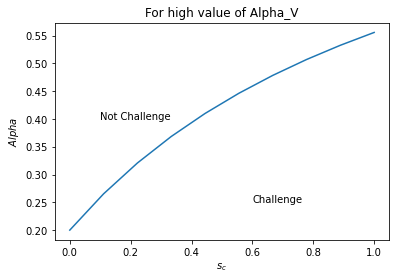

In [10]:
alpha_C = lambdify(['s_c'], alp_NC_Voter_VeVT.subs([(muH, 0.7), (muL, -0.2), (dc, 0.8)]))
print("The threshold value of alpha above which the Challenger will Not Challenge is, given $s_c = 0.6$, is ", alpha_C(0.6))
x = np.linspace(0,1,10)
plt.plot(x, alpha_C(x))
plt.text(.1, .4, "Not Challenge")
plt.text(.6, .25, "Challenge")
plt.xlabel("$s_c$")
plt.ylabel('$Alpha$')
plt.title("For high value of Alpha_V")
plt.show()

##### When the challenger Verify, they will Not Challenge if High quality and Challenge (and win) if Low quality. 
##### This happens with the assumptions: $s_c d_c > \mu_L$ Is this assumption valid ????

 #### Case 3: If $\alpha_0 > \alpha_V$ and $c_{voter} < c_{VH}$  , in this case the voter will always verify and vote truthfully

Case 3.1: When $ \alpha > \alpha_{C}$  , meaning with this sufficiently high value of probability, the challenger does Not Challenge when they decide Not Verify. This condition implies the payoff of the challenger in case of Not Verify is obtained when they do Not Challenge.
Taking this into calculating the threshold of verifying cost for the Challenger. The payoff of Verifying and Not verifying are computed below

In [11]:
# The payoff of the challenger when they Verify and act truthfully and the voter verify and vote truthfully
C_Ve_payoff = alp*(- c +muH) + (1 - alp)*(sc*dc - c)
C_NVe_payoff_H_Voter_VeVT = C_NC_payoff
# The cost threshold above which the challenger will Not Verify
C_cost_thres_NVe_HiAlp_Voter_VeVT = solve(C_NVe_payoff_H_Voter_VeVT - C_Ve_payoff, c)[0]
print("The cost threshold $c_{CH}$ is ")
factor(C_cost_thres_NVe_HiAlp_Voter_VeVT)

The cost threshold $c_{CH}$ is 


-(alpha - 1)*(d_c*s_c - mu_L)

In this case 3.1,  $c_{VH} < c_{CH}$, hence it's always that $c < c_{CH}$, and so the challenger always verify and act truthfully in this case

##### Case 3.2: When $\alpha <\alpha_{C}$, meaning the challenger always Challenge when they decide Not Verify. This condition implies the payoff of the challenger in case of Not Verify is obtained when they Challenge 

In [12]:
C_NVe_Chal_payoff_L_Voter_VeVT = C_C_payoff_Voter_VeVT
# The cost threshold above which the challenger will Not Verify
C_cost_thres_NVe_LoAlp_Voter_VeVT = solve(C_NVe_Chal_payoff_L_Voter_VeVT - C_Ve_payoff, c)[0]
C_cost_thres_NVe_LoAlp_Voter_VeVT

alpha*d_c

In this case 3.2,  if $c > c_{CH}$, the challenger will not Verify and hence Challenge (with sufficiently high $\pi$). Otherwise, the challenger will verify and Challenge if Low quality and Not Challenge if High quality

#### Case 4: When $\alpha_2 < \frac{-\mu_L}{\mu_H - \mu_L}$ and $c > \alpha_2 \mu_L$, the voter does not verify and always votes against
If $s_c d_c > \alpha\mu_H +(1 - \alpha)\mu_L$,ie \
$\alpha_2 < \frac{\mu_L + s_cd_c}{\mu_H - \mu_L}$ \
they will always challenge and win a payoff $s_cd_c$ and the applicant will be voted out and make a loss $d_c$\
If $\alpha_2 >\frac{\mu_L + s_cd_c}{\mu_H - \mu_L}$,\
the challenger will Not Challenge and the applicant will be voted in \
When the challenger choose (NVe, C), $\alpha_2 = \alpha_1$. When the challenger assignsa voter's belief such that the voter will choose (NVe, VA), this will happen if the challenger's belief $\alpha_1$ is such that $\alpha_1 < \frac{s_cd_c - \mu_L}{\mu_H - \mu_L}$, since $\alpha_1 = \alpha_2$ in this challenger's strategy, the challenger will stick to (NVe, C)
=> the challenger will always challenge and win a payoff $s_cd_c$ and the applicant will be voted out and make a loss $d_c$

In [13]:
#The challenger's payoff when they blindly challenge, with the belief that the voter will blindly vote against
C_NVe_Chal_payoff_Voter_NVeVA = sc*dc
#The challenger's payoff when they blindly not challenge, with the belief that the voter will blindly vote against
C_NVE_NC_payoff_Voter_NVeVA = C_NC_payoff
#The alpha threshold above which the challenger will not challenge
alp_NC_Voter_NVeVA = solve(C_NVE_NC_payoff_Voter_NVeVA - C_NVe_Chal_payoff_Voter_NVeVA, alp)[0]
alp_NC_Voter_NVeVA

(d_c*s_c - mu_L)/(mu_H - mu_L)

The threshold value of alpha above which the Challenger will Not Challenge is, given $s_c = 0.6$, is  0.7555555555555553


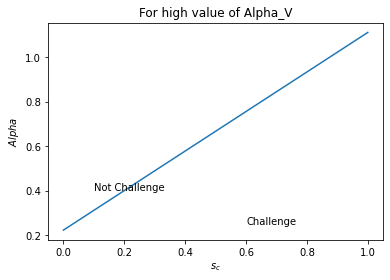

In [14]:
alpha_C_NVeVA = lambdify(['s_c'], alp_NC_Voter_NVeVA.subs([(muH, 0.7), (muL, -0.2), (dc, 0.8)]))
print("The threshold value of alpha above which the Challenger will Not Challenge is, given $s_c = 0.6$, is ", alpha_C_NVeVA(0.6))
x = np.linspace(0,1,10)
plt.plot(x, alpha_C_NVeVA(x))
plt.text(.1, .4, "Not Challenge")
plt.text(.6, .25, "Challenge")
plt.xlabel("$s_c$")
plt.ylabel('$Alpha$')
plt.title("For high value of Alpha_V")
plt.show()

#### Case 4.1: When the challenger's belief is $\alpha_1 < \frac{\mu_L + s_cd_c}{\mu_H - \mu_L}$, the challenger will challenge and not verify when the cost is too high

In [15]:
#The challenger's payoff when they verify and challenge truthfully: C_Ve_payoff

# The cost threshold above which the challenger will Not Verify and blindly challene
C_cost_thres_NVe_LoAlp_Voter_NVeVA = solve(C_NVe_Chal_payoff_Voter_NVeVA - C_Ve_payoff, c)[0]
C_cost_thres_NVe_LoAlp_Voter_NVeVA

alpha*(-d_c*s_c + mu_H)

#### Case 4.1: When the challenger's belief is $\alpha_1 > \frac{\mu_L + s_cd_c}{\mu_H - \mu_L}$, the challenger will not challenge and not verify when the cost is too high

In [16]:
# The cost threshold above which the challenger will blindly not challenge
C_cost_thres_NVe_HiAlp_Voter_NVeVA = solve(C_NC_payoff - C_Ve_payoff, c)[0]
C_cost_thres_NVe_HiAlp_Voter_NVeVA
factor(C_cost_thres_NVe_HiAlp_Voter_NVeVA)


-(alpha - 1)*(d_c*s_c - mu_L)

#### When the voter's belief support their strategy (NVE, VA)

In [17]:
c_CH_Voter_NVeVA = lambdify(['alpha'], C_cost_thres_NVe_HiAlp_Voter_NVeVA.subs([(dc,0.8), (sc, 0.6), (muL, -0.2)]))
c_CL_Voter_NVeVA = lambdify(['alpha'], C_cost_thres_NVe_LoAlp_Voter_NVeVA.subs([(dc,0.8), (sc, 0.6), (muH, 0.7)]))


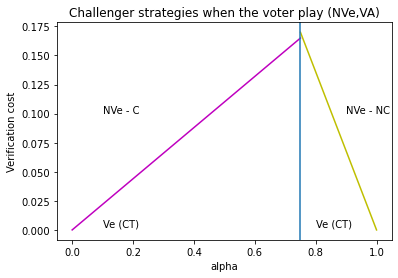

In [18]:
b = np.linspace(0,0.75,100)
a = np.linspace(0.75,1,100)
plt.plot(a, c_CH_Voter_NVeVA(a), 'y')
plt.plot(b, c_CL_Voter_NVeVA(b), 'm')
plt.axvline(x=0.75)
plt.text(.1, .1, "NVe - C")
plt.text(.9, .1, "NVe - NC")
plt.text(.1, .0025, "Ve (CT)")
plt.text(.8, .0025, "Ve (CT)")
plt.xlabel("alpha")
plt.ylabel('Verification cost')

plt.title('Challenger strategies when the voter play (NVe,VA)')
plt.show()

In [ ]:
#### When the voter's belief support their strategy (Ve, VT)

In [19]:
c_CH_Voter_VeVT = lambdify(['alpha'], C_cost_thres_NVe_HiAlp_Voter_VeVT.subs([(dc,0.8), (sc, 0.6), (muL, -0.2)]))
c_CL_Voter_VeVT = lambdify(['alpha'], C_cost_thres_NVe_LoAlp_Voter_VeVT.subs([(dc,0.8), (sc, 0.6), (muH, 0.7)]))


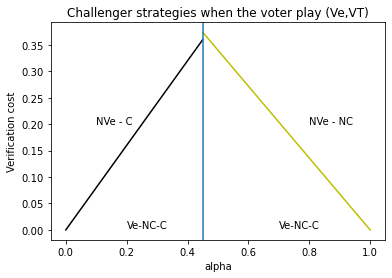

In [20]:
b = np.linspace(0,0.45,100)
a = np.linspace(0.45,1,100)
c = np.linspace(0,0.75,100)
plt.plot(a, c_CH_Voter_VeVT(a), 'y')
plt.plot(b, c_CL_Voter_VeVT(b), 'k')
#plt.plot(c, c_CL_Voter_NVeVA(c), 'm')
plt.axvline(x=0.45)
plt.text(.1, .2, "NVe - C")
plt.text(.8, .2, "NVe - NC")
plt.text(.2, .0025, "Ve-NC-C")
plt.text(.7, .0025, "Ve-NC-C")
#plt.text(0.2, 0.1, "???")
#plt.text(0.5, 0.2, "???")
plt.xlabel("alpha")
plt.ylabel('Verification cost')

plt.title('Challenger strategies when the voter play (Ve,VT)')
plt.show()

 Case 4: If  $\alpha_0 < \alpha_V$ and $c < c_{VL}$  , in this case the voter will always verify and vote truthfully.\
 Since $\alpha_0 < \alpha_V$ => $c_{VL}<c_{CH}$

In [34]:
b = np.linspace(0,0.42,100)
a = np.linspace(0.42,1,100)
plt.plot(a, c_CH(a), 'w')
plt.plot(b, c_CL(b), 'm')
plt.axvline(x=0.42)
plt.text(.04, .25, "NVe - C")
plt.text(.1, .0025, "Ve (CT)")
plt.text(.6, .2, "Ve (CT)")
plt.xlabel("alpha")
plt.ylabel('Verification cost')

plt.title('Challenger strategies for low value of alpha, alpha < alpha_V')
plt.show()

NameError: name 'c_CH' is not defined

### What about when $\pi < \pi_V$ and $c < c_{VL}$???